The DATA PREPARATION PIPELINE that you will perform on the assigned dataset will have the following steps:
1. Data profiling and data quality assessment
2. Data cleaning<br>
  a. Data transformation/standardization (bringing everything to the same format, detecting and correcting typos,
  performing wrangling operations, etc.)<br>
  b. Error detection and correction (dealing with missing values and the detection and correction of potential outliers)<br>
  c. Data deduplication (detecting and handling non-exact duplicates)<br>

Important After cleaning the data, verify the desired quality level has been achieved (additional data quality assessment — brief)<br>

N.B. The dataset to be cleaned is artworks. Use the artists dataset as an external source to clean the main one<br>

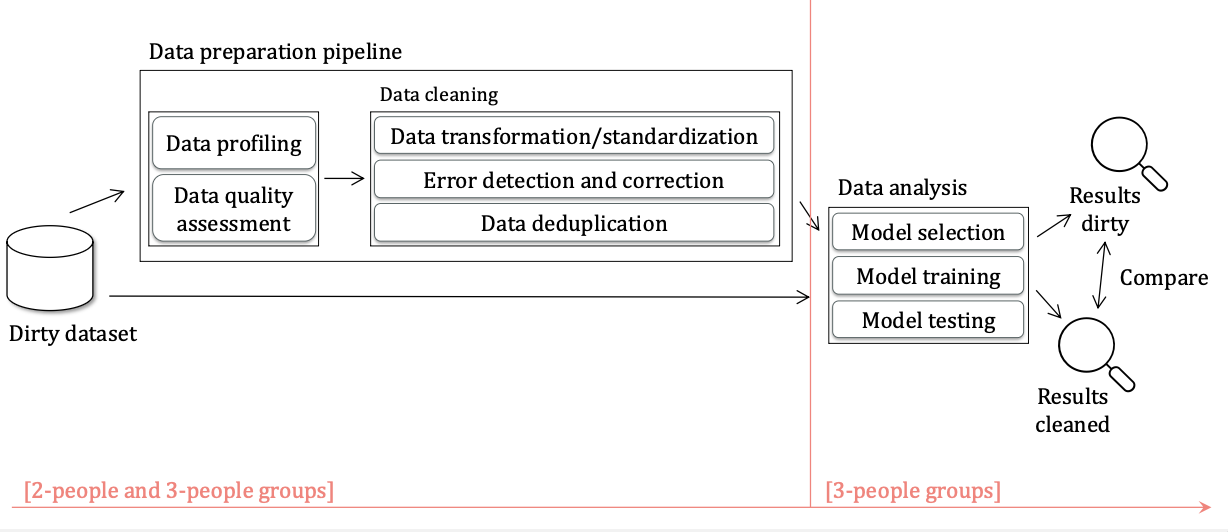


Preparation stage

Download dataset and install libraries

Import libraries

In [ ]:
from ydata_profiling import ProfileReport
from datetime import datetime
#import lux
import json
import numpy as np
import pandas as pd
import seaborn as sns
from efficient_apriori import apriori
import plotly.express as px
import matplotlib.pyplot as plt
import missingno as mno
import re
import difflib
%matplotlib inline
import pandas as pd
import numpy as np
import missingno as mno
import kagglehub
from sklearn import linear_model
from sklearn import ensemble
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from DATADIQ import scripts_for_E5 as s

Load data

In [ ]:
# Download the latest version of the dataset
dataset_path = kagglehub.dataset_download("momanyc/museum-collection")

print("Path to dataset files:", dataset_path)
missing_tokens = ["", "\n"]
ARTWORKS = pd.read_csv(dataset_path + "/artworks.csv", na_values=missing_tokens)
ARTISTS = pd.read_csv(dataset_path + "/artists.csv", na_values=missing_tokens)

1) Data Profiling Section
- Cardinalities
- Value Distributions
- Data Types

In [ ]:
display(ARTWORKS.columns)
display(ARTWORKS.head())
print("Shape:", ARTWORKS.shape)
display(ARTWORKS.dtypes)
display(ARTWORKS.describe(include="all").T.head(5))

In [ ]:
display(ARTISTS.columns)
display(ARTISTS.head())
print("Shape:", ARTISTS.shape)
display(ARTISTS.dtypes)
display(ARTISTS.describe(include="all").T.head(5))

Check for duplicates

In [ ]:
ARTWORKS.duplicated().any()

In [ ]:
ARTISTS.duplicated().any()

In [ ]:
# Duplicates
print("ARTWORKS")
dup_exact = int(ARTWORKS.duplicated().sum())
dup_object = int(ARTWORKS.duplicated(subset=["Object Number"]).sum()) if "Object Number" in ARTWORKS.columns else None
print("Exact duplicate rows:", dup_exact)
print("Duplicates by Object Number:", dup_object)
print("ARTISTS")
dup_exact = int(ARTWORKS.duplicated().sum())
dup_object = int(ARTWORKS.duplicated(subset=["Object Number"]).sum()) if "Object Number" in ARTWORKS.columns else None
print("Exact duplicate rows:", dup_exact)
print("Duplicates by Object Number:", dup_object)

In [ ]:
# Missingness profiling (top 20 + chart top 15)
missing_pct = (ARTWORKS.isna().mean()*100).sort_values(ascending=False)
display(missing_pct.to_frame("% missing").head(20))

top = missing_pct.head(15).sort_values()
plt.figure()
plt.barh(top.index, top.values)
plt.xlabel("% missing")
plt.title("Top-15 columns by missingness (artworks)")
plt.show()

In [ ]:
# Missingness visualization
mno.matrix(ARTWORKS)
plt.show()


In [ ]:
def get_metrics(df, missing_tokens):
  METRICS = pd.DataFrame(columns=['Field Name', 'NULL', 'Missing', 'Actual', 'Completeness', 'Cardinality', 'Uniqueness', 'Distinctness'])
  METRICS['Field Name'] = df.columns

  missings = {}
  total_rows = len(df)
  for i, c in enumerate(df.columns):
    col = df[c]

    null_mask = col.isna()
    null_count = null_mask.sum()

    missing_mask = col.astype(str).str.lower().isin(missing_tokens)
    missing_count = missing_mask.sum()
    missings[c] = df.loc[missing_mask, ['Artwork ID', c]]

    cardinality_count = col[~null_mask & ~missing_mask].nunique()

    actual_count = total_rows - (null_count+missing_count)

    if total_rows > 0:
      completeness = actual_count/total_rows
      uniqueness = cardinality_count/total_rows
    else:
      completeness = np.nan
      uniqueness = np.nan

    if actual_count > 0:
      distinctness = cardinality_count/actual_count
    else:
      distinctness = np.nan

    METRICS.loc[i, 'NULL'] = null_count
    METRICS.loc[i, 'Missing'] = missing_count
    METRICS.loc[i, 'Actual'] = actual_count
    METRICS.loc[i, 'Completeness'] = completeness
    METRICS.loc[i, 'Cardinality'] = cardinality_count
    METRICS.loc[i, 'Uniqueness'] = uniqueness
    METRICS.loc[i, 'Distinctness'] = distinctness

  METRICS.style.format({
      "Completeness": "{:.2%}",
      "Uniqueness": "{:.2%}",
      "Distinctness": "{:.2%}"
  })
  return METRICS, missings
ARTWORKS_METRICS, missings = get_metrics(ARTWORKS, ["unknown", "-", " "])
ARTWORKS_METRICS

We use `artists.csv` as an external source to:
- validate that artist IDs referenced in artworks exist (referential integrity)
- recover missing `Name` when we can map `Artist ID` → `Name`

MoMA detail:
- `Artist ID` may contain multiple IDs: `"123, 456"` → we derive **Primary Artist ID** (first ID) for recovery.

In [ ]:

def parse_artist_ids(val) -> list:
    if pd.isna(val):
        return []
    if isinstance(val, (int, np.integer)):
        return [int(val)]
    s = str(val).strip()
    if not s:
        return []
    parts = re.split(r"[;,]", s)
    out = []
    for p in parts:
        p = p.strip()
        if not p:
            continue
        if p.isdigit():
            out.append(int(p))
            continue
        digits = re.findall(r"\d+", p)
        if digits:
            out.append(int(digits[0]))
    return out

def parse_primary_artist_id(val):
    ids = parse_artist_ids(val)
    return ids[0] if ids else np.nan

# Build artist lookup
if "Artist ID" not in ARTISTS.columns or "Name" not in ARTISTS.columns:
    raise ValueError("artists.csv must contain 'Artist ID' and 'Name'")

ARTISTS_IDS = set(ARTISTS["Artist ID"].dropna().astype(int).tolist())
ARTISTS_NAME_BY_ID = dict(zip(ARTISTS["Artist ID"].dropna().astype(int), ARTISTS["Name"].astype(str)))

# Referential integrity check
if "Artist ID" in ARTWORKS.columns:
    parsed_all = ARTWORKS["Artist ID"].apply(parse_artist_ids)
    all_ids = set([i for sub in parsed_all.tolist() for i in sub])
    not_found = sorted(list(all_ids - ARTISTS_IDS))
    print("Unique artist IDs referenced by artworks (parsed):", len(all_ids))
    print("Artist IDs not found in artists.csv:", len(not_found))
    not_found[:20]
else:
    print("No 'Artist ID' column in artworks.")

In [ ]:
# Recovery feasibility for missing Name
if "Name" in ARTWORKS.columns and "Artist ID" in ARTWORKS.columns:
    name_missing_mask = ARTWORKS["Name"].isna() | ARTWORKS["Name"].astype(str).str.lower().isin({"unknown","-"," "})
    subset_cols = ["Artist ID","Name"]
    if "Artwork ID" in ARTWORKS.columns:
        subset_cols = ["Artwork ID"] + subset_cols
    subset = ARTWORKS.loc[name_missing_mask, subset_cols].copy()
    subset["Primary Artist ID"] = subset["Artist ID"].apply(parse_primary_artist_id)

    recoverable = subset["Primary Artist ID"].notna() & subset["Primary Artist ID"].isin(ARTISTS_IDS)

    print("Rows with missing/token Name:", len(subset))
    print("Recoverable from artists.csv (primary artist):", int(recoverable.sum()))
    print("Not recoverable:", int((~recoverable).sum()))
    subset.loc[recoverable].head(10)
else:
    print("Skipping Name recovery feasibility check.")

In [ ]:
actually_missing_artists = []
actually_missing_names = []

for _, row in missings['Name'].iterrows():
    artwork_id = row['Artwork ID']
    artist_name = row['Name']

    # Get the Artist ID from ARTWORKS
    artist_id_series = ARTWORKS.loc[ARTWORKS['Artwork ID'] == artwork_id, 'Artist ID']

    if artist_id_series.empty:
        continue  # skip if no Artist ID found

    artist_id = int(artist_id_series.values[0])

    # Create a copy of the row and add Artist ID
    row_with_id = row.copy()
    row_with_id['Artist ID'] = artist_id

    # Check if Artist ID exists in ARTISTS
    if artist_id not in ARTISTS['Artist ID'].values:
        actually_missing_artists.append(row_with_id)

    # Check if the name matches
    artist_row = ARTISTS.loc[ARTISTS['Artist ID'] == artist_id]
    if not artist_row.empty:
        if artist_name != artist_row['Name'].values[0]:
            actually_missing_names.append(row_with_id)

if len(actually_missing_artists)==0 and len(actually_missing_names)==0:
  print('Names actually do not have missing values')
  name_idx = 3


  # Update Actual count (total_rows - NULL - Missing)
  total_rows = len(ARTWORKS)
  null_count = ARTWORKS_METRICS.loc[name_idx, 'NULL']
  actual_count = total_rows - null_count
  cardinality_count = ARTWORKS_METRICS.loc[name_idx, 'Cardinality'] + missings['Name']['Name'].nunique()

  if total_rows > 0:
    completeness = actual_count/total_rows
    uniqueness = cardinality_count/total_rows
  else:
    completeness = np.nan
    uniqueness = np.nan

  if actual_count > 0:
    distinctness = cardinality_count/actual_count
  else:
    distinctness = np.nan

  ARTWORKS_METRICS.loc[name_idx, 'Missing'] = 0
  ARTWORKS_METRICS.loc[name_idx, 'Actual'] = actual_count
  ARTWORKS_METRICS.loc[name_idx, 'Completeness'] = completeness
  ARTWORKS_METRICS.loc[name_idx, 'Cardinality'] = cardinality_count
  ARTWORKS_METRICS.loc[name_idx, 'Uniqueness'] = uniqueness
  ARTWORKS_METRICS.loc[name_idx, 'Distinctness'] = distinctness

ARTWORKS_METRICS


In [ ]:
ARTWORKS_PROFILE = ProfileReport(ARTWORKS, title="Artworks Data Profile Report")
ARTWORKS_PROFILE

In [ ]:
ARTISTS_PROFILE = ProfileReport(ARTISTS, title="Artworks Data Profile Report")
ARTISTS_PROFILE

2) Data Cleaning
- 0) Start from Dirty
- 1) Token Definition + Helpers
- 2) Data Standarization
- 3) Error Correction
- 4) Outlier Detection
- 5) Duplicate Detection
- 6) Association Rule
- EXTRA
- 7) Data Quality Assessment

In [ ]:
mno.matrix(ARTWORKS)

In [ ]:
# -----------------------------
# 0) START FROM DIRTY
# -----------------------------
ARTWORKS_CLEAN = ARTWORKS.copy()


In [ ]:
# -----------------------------
# 1) DEFINE TOKENS + HELPERS
# -----------------------------
MISSING_TOKENS = {"unknown", "Unknown", "UNKNOWN", "-", " ", ""}

def clean_text_series(s: pd.Series) -> pd.Series:
    """Normalize whitespace and dash characters; keep as string dtype."""
    s = s.astype("string")
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    s = s.str.replace("–", "-", regex=False).str.replace("—", "-", regex=False)
    return s

def normalize_unknown_tokens_text(s: pd.Series) -> pd.Series:
    """Map unknown-like tokens to 'missing' for text columns."""
    s = clean_text_series(s)
    # case-insensitive token normalization
    low = s.astype("string").str.lower()
    s = s.mask(low.isin({t.lower() for t in MISSING_TOKENS}), "missing")
    return s

def compute_missing_ratio(series: pd.Series, is_text: bool) -> float:
    """Missing ratio considering NA + unknown tokens (for text)."""
    na = series.isna()
    if not is_text:
        return float(na.mean())
    low = series.astype("string").str.strip().str.lower()
    tok = low.isin({t.lower() for t in MISSING_TOKENS} | {"missing"})
    return float((na | tok).mean())
def parse_artist_ids(val) -> list:
    """Parse multi-valued Artist ID cells into a list of ints."""
    if pd.isna(val):
        return []
    if isinstance(val, (int, np.integer)):
        return [int(val)]
    s = str(val).strip()
    if not s:
        return []
    parts = re.split(r"[;,]", s)
    out = []
    for p in parts:
        p = p.strip()
        if not p:
            continue
        digits = re.findall(r"\d+", p)
        if digits:
            out.append(int(digits[0]))
    return out

def parse_primary_artist_id(val):
    ids = parse_artist_ids(val)
    return ids[0] if ids else np.nan
def first_valid_artist_id(ids, valid_ids_set):
    """Return the first artist id from ids that exists in artists.csv (valid_ids_set), else NaN."""
    if ids is None:
        return np.nan
    # ids expected to be a list (possibly empty)
    for i in ids:
        try:
            ii = int(i)
        except Exception:
            continue
        if ii in valid_ids_set:
            return ii
    return np.nan

In [ ]:
# -----------------------------
# 2) Data Standarization (COLUMN-BY-COLUMN TRANSFORMATION / MISSING VALUE HANDLING)
# -----------------------------

# (A) TEXT / CATEGORICAL COLUMNS
# Title: text -> fill missing with "missing"
if "Title" in ARTWORKS_CLEAN.columns:
    ARTWORKS_CLEAN["Title"] = normalize_unknown_tokens_text(ARTWORKS_CLEAN["Title"]).fillna("missing")

# Date: free-text -> normalize tokens + keep text; then extract year range
if "Date" in ARTWORKS_CLEAN.columns:
    ARTWORKS_CLEAN["Date"] = normalize_unknown_tokens_text(ARTWORKS_CLEAN["Date"]).fillna("missing")

# Medium: text -> normalize tokens + fill
if "Medium" in ARTWORKS_CLEAN.columns:
    ARTWORKS_CLEAN["Medium"] = normalize_unknown_tokens_text(ARTWORKS_CLEAN["Medium"]).fillna("missing")

# Dimensions: text -> normalize tokens + fill
if "Dimensions" in ARTWORKS_CLEAN.columns:
    ARTWORKS_CLEAN["Dimensions"] = normalize_unknown_tokens_text(ARTWORKS_CLEAN["Dimensions"]).fillna("missing")

# Credit: text -> normalize tokens + fill
if "Credit" in ARTWORKS_CLEAN.columns:
    ARTWORKS_CLEAN["Credit"] = normalize_unknown_tokens_text(ARTWORKS_CLEAN["Credit"]).fillna("missing")

# Department / Classification: categorical text -> normalize
for c in ["Department", "Classification"]:
    if c in ARTWORKS_CLEAN.columns:
        ARTWORKS_CLEAN[c] = normalize_unknown_tokens_text(ARTWORKS_CLEAN[c])

# Catalogue: usually boolean-like/flag -> keep as is (if present)
if "Catalogue" in ARTWORKS_CLEAN.columns:
    # ensure consistent text representation if it is object
    if ARTWORKS_CLEAN["Catalogue"].dtype == "object":
        ARTWORKS_CLEAN["Catalogue"] = clean_text_series(ARTWORKS_CLEAN["Catalogue"])

In [ ]:
# (B) ARTIST ID + EXTERNAL SOURCE (artists.csv)

if "Artist ID" in ARTWORKS_CLEAN.columns:
    ARTWORKS_CLEAN["Artist ID Raw"] = ARTWORKS_CLEAN["Artist ID"].astype("string")
    ARTWORKS_CLEAN["Artist ID Missing Flag"] = ARTWORKS_CLEAN["Artist ID"].isna()
    ARTWORKS_CLEAN["Artist IDs Parsed"] = ARTWORKS_CLEAN["Artist ID"].apply(parse_artist_ids)
    ARTWORKS_CLEAN["Artist Count"] = ARTWORKS_CLEAN["Artist IDs Parsed"].apply(len)
    ARTWORKS_CLEAN["Primary Artist ID"] = ARTWORKS_CLEAN["Artist ID"].apply(parse_primary_artist_id)

# Build lookup from ARTISTS
if "Artist ID" not in ARTISTS.columns or "Name" not in ARTISTS.columns:
    raise ValueError("artists.csv must contain 'Artist ID' and 'Name'")

ARTISTS_IDS = set(ARTISTS["Artist ID"].dropna().astype(int).tolist())
ARTISTS_NAME_BY_ID = dict(zip(ARTISTS["Artist ID"].dropna().astype(int), ARTISTS["Name"].astype(str)))

# Referential integrity: all referenced artist IDs exist in artists.csv
if "Artist ID" in ARTWORKS_CLEAN.columns:
    all_ids = set([i for sub in ARTWORKS_CLEAN["Artist IDs Parsed"].tolist() for i in sub])
    not_found = sorted(list(all_ids - ARTISTS_IDS))
    print("Unique artist IDs referenced by artworks (parsed):", len(all_ids))
    print("Artist IDs not found in artists.csv:", len(not_found))
    print("Sample not found:", not_found[:20])

In [ ]:
# Name: normalize tokens; recover from artists.csv using the first VALID Artist ID in the parsed list;
# optionally update Primary Artist ID to the ID used for recovery; then fill remaining with "missing"

if "Name" in ARTWORKS_CLEAN.columns:
    # 1) Normalize Name tokens
    ARTWORKS_CLEAN["Name"] = normalize_unknown_tokens_text(ARTWORKS_CLEAN["Name"])

    name_missing_mask = (
        ARTWORKS_CLEAN["Name"].isna()
        | ARTWORKS_CLEAN["Name"].astype(str).str.strip().str.lower().isin({"missing", "unknown", "-", ""})
    )

    # 2) Recover Name using artists.csv
    if "Artist IDs Parsed" in ARTWORKS_CLEAN.columns:
        # choose first valid ID from the list (may be 2nd/3rd if 1st is invalid)
        ARTWORKS_CLEAN["Primary Artist ID (name-based)"] = ARTWORKS_CLEAN["Artist IDs Parsed"].apply(
            lambda ids: first_valid_artist_id(ids, ARTISTS_IDS)
        )

        recover_mask = ARTWORKS_CLEAN["Primary Artist ID (name-based)"].notna()
        fill_mask = name_missing_mask & recover_mask

        ARTWORKS_CLEAN.loc[fill_mask, "Name"] = ARTWORKS_CLEAN.loc[
            fill_mask, "Primary Artist ID (name-based)"
        ].map(ARTISTS_NAME_BY_ID)

        print("Filled Name from artists.csv (first valid ID in list):", int(fill_mask.sum()))

        # OPTIONAL: update Primary Artist ID to the one that produced the recovered name
        if "Primary Artist ID" in ARTWORKS_CLEAN.columns:
            ARTWORKS_CLEAN["Primary Artist ID Changed Flag"] = False
            change_mask = fill_mask & (
                ARTWORKS_CLEAN["Primary Artist ID"].astype("Float64")
                != ARTWORKS_CLEAN["Primary Artist ID (name-based)"].astype("Float64")
            )
            ARTWORKS_CLEAN.loc[change_mask, "Primary Artist ID"] = ARTWORKS_CLEAN.loc[
                change_mask, "Primary Artist ID (name-based)"
            ]
            ARTWORKS_CLEAN.loc[change_mask, "Primary Artist ID Changed Flag"] = True
            print("Primary Artist ID updated (due to name recovery):", int(change_mask.sum()))
    else:
        print("Skipping Name recovery: 'Artist IDs Parsed' not available.")

    # 3) Fill remaining missing Name
    ARTWORKS_CLEAN["Name"] = ARTWORKS_CLEAN["Name"].fillna("missing")

# Consistency sanity check (ArtistID missing XOR Name missing-token)
if "Artist ID" in ARTWORKS_CLEAN.columns and "Name" in ARTWORKS_CLEAN.columns:
    artist_missing = ARTWORKS_CLEAN["Artist ID"].isna()
    name_missing = (
        ARTWORKS_CLEAN["Name"].isna()
        | ARTWORKS_CLEAN["Name"].astype(str).str.strip().str.lower().isin({"missing"})
    )
    inconsistent = ARTWORKS_CLEAN[artist_missing ^ name_missing]
    print("ArtistID/Name inconsistency rows:", len(inconsistent))
    if len(inconsistent) > 0:
        show_cols = [c for c in ["Artwork ID", "Artist ID", "Artist ID Raw", "Primary Artist ID", "Name"] if c in ARTWORKS_CLEAN.columns]
        display(inconsistent[show_cols].head(10))


In [ ]:
# (C) ACQUISITION DATE — parse (do NOT overwrite with "missing")
if "Acquisition Date" in ARTWORKS_CLEAN.columns:
    ARTWORKS_CLEAN["Acquisition Date (parsed)"] = pd.to_datetime(ARTWORKS_CLEAN["Acquisition Date"], errors="coerce")
    invalid_acq = ARTWORKS_CLEAN["Acquisition Date"].notna() & ARTWORKS_CLEAN["Acquisition Date (parsed)"].isna()
    print("Invalid acquisition dates:", int(invalid_acq.sum()))
    if invalid_acq.sum() > 0:
        display(ARTWORKS_CLEAN[invalid_acq][["Artwork ID", "Acquisition Date"]].head(10))

        #drop the single row with out of range datetime
        index_to_drop = ARTWORKS_CLEAN[ARTWORKS_CLEAN["Artwork ID"] == 215774].index
        ARTWORKS_CLEAN = ARTWORKS_CLEAN.drop(index_to_drop)
        invalid_acq = ARTWORKS_CLEAN["Acquisition Date"].notna() & ARTWORKS_CLEAN["Acquisition Date (parsed)"].isna()
        #Assume first day of the month for dates without day
        fixed_dates = ARTWORKS_CLEAN.loc[invalid_acq, "Acquisition Date"].astype(str) + "-01"
        ARTWORKS_CLEAN.loc[invalid_acq, "Acquisition Date (parsed)"] = pd.to_datetime(
            fixed_dates, errors="coerce"
        )


# (D) DATE YEAR RANGE EXTRACTION (from free-text Date)
def extract_year_range(date_str):
    if pd.isna(date_str):
        return (np.nan, np.nan)
    s = str(date_str)
    years = re.findall(r"(?:18|19|20)\d{2}", s)
    if years:
        ys = [int(y) for y in years]
        return (min(ys), max(ys))
    m = re.search(r"((?:18|19|20)\d{2})\s*[-/]\s*(\d{2})\b", s)
    if m:
        y1 = int(m.group(1))
        y2_2 = int(m.group(2))
        century = y1 // 100
        y2 = century * 100 + y2_2
        if y2 < y1:
            y2 = (century + 1) * 100 + y2_2
        return (y1, y2)
    m = re.search(r"((?:18|19|20)\d{2})s\b", s)
    if m:
        y = int(m.group(1))
        return (y, y + 9)
    return (np.nan, np.nan)

if "Date" in ARTWORKS_CLEAN.columns:
    yrs = ARTWORKS_CLEAN["Date"].apply(extract_year_range)
    ARTWORKS_CLEAN["Date Year Start"] = [y[0] for y in yrs]
    ARTWORKS_CLEAN["Date Year End"]   = [y[1] for y in yrs]


In [ ]:
measure_cols = [
    "Height (cm)", "Width (cm)", "Length (cm)", "Depth (cm)",
    "Diameter (cm)", "Circumference (cm)", "Weight (kg)", "Duration (s)"
]
measure_cols = [c for c in measure_cols if c in ARTWORKS_CLEAN.columns]

dims_missing = ARTWORKS_CLEAN["Dimensions"].astype(str).str.strip().str.lower().isin({"missing", "unknown", "-", ""}) | ARTWORKS_CLEAN["Dimensions"].isna()

SUB = ARTWORKS_CLEAN.loc[dims_missing, ["Artwork ID","Title","Department","Classification","Medium","Dimensions"] + measure_cols].copy()
print("Rows where Dimensions is missing/token:", len(SUB))

# How many of these have each measurement available?
avail = (SUB[measure_cols].notna().sum()).sort_values(ascending=False)
display(avail.to_frame("non-null count"))


In [ ]:
physical_measures = ["Height (cm)","Width (cm)","Length (cm)","Depth (cm)","Diameter (cm)","Circumference (cm)"]
physical_measures = [c for c in physical_measures if c in SUB.columns]

physical = SUB[SUB[physical_measures].notna().any(axis=1) & SUB["Duration (s)"].isna()].copy()
print("Dimensions missing but some physical measure present (no duration):", len(physical))
display(physical[["Artwork ID","Title","Dimensions"] + physical_measures + ["Department","Classification","Medium"]].head(20))


In [ ]:
mask_time_based_only = (
    dims_missing
    & ARTWORKS_CLEAN["Duration (s)"].notna()
    & (ARTWORKS_CLEAN["Duration (s)"] > 0)
    & (
        ARTWORKS_CLEAN[physical_measures].isna().all(axis=1)
        if len(physical_measures) > 0 else True
    )
)

print("Rows with Duration present + Dimensions missing + no other physical measures:", int(mask_time_based_only.sum()))

cols_show = [c for c in ["Artwork ID","Title","Department","Classification","Medium","Dimensions","Duration (s)"] if c in ARTWORKS_CLEAN.columns]
display(ARTWORKS_CLEAN.loc[mask_time_based_only, cols_show].head(20))


In [ ]:
truly_missing = SUB[SUB[measure_cols].isna().all(axis=1)].copy()
print("Dimensions missing and no other measures present:", len(truly_missing))
display(truly_missing[["Artwork ID","Title","Department","Classification","Medium","Dimensions"]].head(20))


In [ ]:
# -----------------------------
# 3) Error Correction (MISSING VALUE DERIVATION & IMPUTATION)
# -----------------------------

# (A) Dimension (deriving from metrics)
# Fill missing values in Dimensions with nonnull values in metrics
cols = ['Diameter (cm)', 'Circumference (cm)', 'Height (cm)', 'Length (cm)', 'Width (cm)', 'Depth (cm)', 'Weight (kg)', 'Duration (s)']
non_null_metrics_mask = (ARTWORKS_CLEAN['Diameter (cm)'].notna() |
ARTWORKS_CLEAN['Circumference (cm)'].notna() |
ARTWORKS_CLEAN['Height (cm)'].notna() |
ARTWORKS_CLEAN['Length (cm)'].notna() |
ARTWORKS_CLEAN['Width (cm)'].notna() |
ARTWORKS_CLEAN['Depth (cm)'].notna() |
ARTWORKS_CLEAN['Weight (kg)'].notna() |
ARTWORKS_CLEAN['Duration (s)'].notna())

missing_dimensions_mask = ARTWORKS_CLEAN['Dimensions'] == 'missing'

rows = ARTWORKS_CLEAN[missing_dimensions_mask & non_null_metrics_mask]

print("Number of rows with missing values in Dimensions and present values in metrics: ", len(rows))

for idx, r in rows.iterrows():  # iterate over rows
    dims = ''
    for c in cols:
        if pd.notna(r[c]):        # use pd.notna() for scalars
            dims += f"{c}: {r[c]}, "
    dims = dims.rstrip(', ')       # remove trailing comma+space
    ARTWORKS_CLEAN.loc[idx, 'Dimensions'] = dims
display(ARTWORKS_CLEAN.loc[rows.index, ['Artwork ID', 'Dimensions']])

In [ ]:
# Fill null Width and Height of rows where the artwork is not measured by them with 0s
null_height_mask = ARTWORKS_CLEAN['Height (cm)'].isna()
null_width_mask = ARTWORKS_CLEAN['Width (cm)'].isna()
non_null_other_metrics_mask = (ARTWORKS_CLEAN['Diameter (cm)'].notna() |
  ARTWORKS_CLEAN['Circumference (cm)'].notna() |
  ARTWORKS_CLEAN['Length (cm)'].notna() |
  ARTWORKS_CLEAN['Depth (cm)'].notna() |
  ARTWORKS_CLEAN['Weight (kg)'].notna() |
  ARTWORKS_CLEAN['Duration (s)'].notna())

rows_na_height = ARTWORKS_CLEAN[null_height_mask & non_null_other_metrics_mask]
rows_na_width = ARTWORKS_CLEAN[null_width_mask & non_null_other_metrics_mask]
print("Number of rows with missing values in Dimensions and Height: ", len(rows_na_height))
print("Number of rows with missing values in Dimensions and Width: ", len(rows_na_width))

# Fill missing Height with 0 in rows where other metrics exist
ARTWORKS_CLEAN.loc[rows_na_height.index, 'Height (cm)'] = 0

# Fill missing Width with 0 in rows where other metrics exist
ARTWORKS_CLEAN.loc[rows_na_width.index, 'Width (cm)'] = 0

In [ ]:
# (B) ML-Based Imputation for Height and Width (classification specific)
missing_dimensions_mask = ARTWORKS_CLEAN['Dimensions'] == 'missing'
rows = ARTWORKS_CLEAN[missing_dimensions_mask]

print("Number of rows with missing values in Dimensions: ", len(rows))

null_height_mask = ARTWORKS_CLEAN['Height (cm)'].isna()
null_width_mask = ARTWORKS_CLEAN['Width (cm)'].isna()
rows_na_dim_height = ARTWORKS_CLEAN[missing_dimensions_mask & null_height_mask]
rows_na_dim_width = ARTWORKS_CLEAN[missing_dimensions_mask & null_width_mask]
rows_na_dim_height_width = ARTWORKS_CLEAN[missing_dimensions_mask & null_height_mask & null_width_mask]
print("Number of rows with missing values in Dimensions and Height: ", len(rows_na_dim_height))
print("Number of rows with missing values in Dimensions and Width: ", len(rows_na_dim_width))
print("Number of rows with missing values in Dimensions and Height and Width: ", len(rows_na_dim_height_width))

# Columns to predict
cols_to_predict = ['Height (cm)', 'Width (cm)']

# Make copies for predictions
for col in cols_to_predict:
    ARTWORKS_CLEAN[f'{col}_predicted'] = ARTWORKS_CLEAN[col]

IMPUTER = KNNImputer(n_neighbors=5)

classifications = ARTWORKS_CLEAN['Classification'].unique()
# Loop over each classification
for cls in classifications:
    class_mask = ARTWORKS_CLEAN['Classification'] == cls
    df_class = ARTWORKS_CLEAN.loc[class_mask, cols_to_predict].copy()
    # Only impute if there are missing values
    if df_class.isna().any().any():
        imputer = KNNImputer(n_neighbors=5)
        df_class_imputed = pd.DataFrame(
            imputer.fit_transform(df_class),
            columns=cols_to_predict,
            index=df_class.index
        )

        # Update predicted columns ONLY where original was NaN (This can be done here since we only consider disjoint classification rows for KNN)
        for col in cols_to_predict:
            pred_col = f'{col}_predicted'
            rows_to_update = df_class.index[df_class[col].isna()]
            ARTWORKS_CLEAN.loc[rows_to_update, pred_col] = df_class_imputed.loc[rows_to_update, col]

# Quick check
print(ARTWORKS_CLEAN[['Height (cm)', 'Height (cm)_predicted',
                      'Width (cm)', 'Width (cm)_predicted']].isna().sum())

rows_missing = ARTWORKS_CLEAN.loc[missing_dimensions_mask]

# Display original vs predicted
display(rows_missing[['Artwork ID', 'Classification', 'Dimensions',
                     'Height (cm)', 'Height (cm)_predicted',
                     'Width (cm)', 'Width (cm)_predicted']])

In [ ]:
# Fill missing values in Dimensions with nonnull values in metrics (again for predicted values)
cols = ['Height (cm)_predicted', 'Width (cm)_predicted']

missing_dimensions_mask = ARTWORKS_CLEAN['Dimensions'] == 'missing'

rows = ARTWORKS_CLEAN[missing_dimensions_mask]

print("Number of rows with missing values in Dimensions and present values in predicted metrics: ", len(rows))

for idx, r in rows.iterrows():  # iterate over rows
    dims = ''
    for c in cols:
        if pd.notna(r[c]):        # use pd.notna() for scalars
            dims += f"{c}: {r[c]}, "
    dims = dims.rstrip(', ')       # remove trailing comma+space
    ARTWORKS_CLEAN.loc[idx, 'Dimensions'] = dims
display(ARTWORKS_CLEAN.loc[rows.index, ['Artwork ID', 'Dimensions']])

In [ ]:
# (C) ML-Based Imputation of Medium with Random Forest
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# --- Features and categorical columns ---
numeric_features = [
    'Diameter (cm)', 'Circumference (cm)', 'Height (cm)_predicted',
    'Length (cm)', 'Width (cm)_predicted', 'Depth (cm)',
    'Weight (kg)', 'Duration (s)'
]
categorical_features = ['Classification']

# --- Step 1: Group rare Mediums ---
medium_counts = ARTWORKS_CLEAN.loc[ARTWORKS_CLEAN['Medium'] != 'missing', 'Medium'].value_counts()
common_mediums = medium_counts[medium_counts > 5].index  # keep mediums with >5 artworks
ARTWORKS_CLEAN['Medium_grouped'] = ARTWORKS_CLEAN['Medium'].where(
    ARTWORKS_CLEAN['Medium'].isin(common_mediums), 'Other'
)

# --- Step 2: Prepare a copy for features ---
df_features = ARTWORKS_CLEAN[numeric_features + categorical_features + ['Medium_grouped']].copy()

# --- Step 3: Encode categorical features ---
for col in categorical_features:
    le = LabelEncoder()
    df_features[col+'_encoded'] = le.fit_transform(df_features[col].astype(str))

# Encode target
medium_le = LabelEncoder()
df_features['Medium_encoded'] = medium_le.fit_transform(df_features['Medium_grouped'].astype(str))

# --- Step 4: Create prediction column ---
ARTWORKS_CLEAN['Medium_imputed'] = ARTWORKS_CLEAN['Medium_grouped']

# --- Step 5: Impute Medium per Classification ---
for cls in ARTWORKS_CLEAN['Classification'].unique():
    class_mask = ARTWORKS_CLEAN['Classification'] == cls
    df_class = df_features[class_mask].copy()

    # Rows with known Medium
    known_mask = df_class['Medium_grouped'] != 'Other'  # only meaningful values
    if known_mask.sum() == 0:
        continue

    X_train = df_class.loc[known_mask, numeric_features + [col+'_encoded' for col in categorical_features]]
    y_train = df_class.loc[known_mask, 'Medium_encoded']

    # Rows to predict
    missing_mask = df_class['Medium_grouped'] == 'Other'
    if missing_mask.sum() == 0:
        continue

    X_missing = df_class.loc[missing_mask, numeric_features + [col+'_encoded' for col in categorical_features]]

    # Train Random Forest
    rf = RandomForestClassifier(n_estimators=50, random_state=42)  # smaller n_estimators to save RAM
    rf.fit(X_train, y_train)

    # Predict
    y_pred_encoded = rf.predict(X_missing)
    y_pred = medium_le.inverse_transform(y_pred_encoded)

    # Fill predictions into main DataFrame
    ARTWORKS_CLEAN.loc[df_class.index[missing_mask], 'Medium_imputed'] = y_pred

# --- Step 6: Quick check ---
print("Number of missing Mediums after imputation:", ARTWORKS_CLEAN['Medium_imputed'].isna().sum())
ARTWORKS_CLEAN[['Medium', 'Medium_grouped', 'Medium_imputed']].head(10)


In [ ]:
# Mask for rows that were missing originally
missing_mask = ARTWORKS_CLEAN['Medium'].isna() | (ARTWORKS_CLEAN['Medium'] == 'missing')

# Update only those rows
ARTWORKS_CLEAN.loc[missing_mask, 'Medium'] = ARTWORKS_CLEAN.loc[missing_mask, 'Medium_imputed']


In [ ]:
# D) DROP COLUMNS WITH > 50% MISSING INFO
CORE_KEEP = {"Artwork ID", "Object Number", "Artist ID", "Name", "Title"}

missing_ratios = {}
for c in ARTWORKS_CLEAN.columns:
    is_text = not pd.api.types.is_numeric_dtype(ARTWORKS_CLEAN[c])
    missing_ratios[c] = compute_missing_ratio(ARTWORKS_CLEAN[c], is_text=is_text)

missing_ratios = pd.Series(missing_ratios).sort_values(ascending=False)
to_drop = missing_ratios[(missing_ratios > 0.50) & (~missing_ratios.index.isin(CORE_KEEP))].index.tolist()

print("Dropping columns (>50% missing info):", to_drop)
ARTWORKS_CLEAN = ARTWORKS_CLEAN.drop(columns=to_drop)

In [ ]:
# ============================================================
# 4) OUTLIER DETECTION — Professor style (IQR + Z-score)
#    -> Inspection + flags only
# ============================================================

# 4.1 Select numeric columns (exclude IDs if you want)
num_cols = ARTWORKS_CLEAN.select_dtypes(include=[np.number]).columns.tolist()
# Optional: exclude identifiers from outlier checks
num_cols = [c for c in num_cols if c not in ["Artwork ID", "Artist ID", "Primary Artist ID"]]

print("Numeric columns considered:", num_cols)

# 4.2 Outlier masks
def iqr_bounds(x: pd.Series):
    xs = x.dropna().astype(float)
    if len(xs) < 10:
        return (np.nan, np.nan)
    q1 = xs.quantile(0.25)
    q3 = xs.quantile(0.75)
    iqr = q3 - q1
    return (q1 - 1.5 * iqr, q3 + 1.5 * iqr)

def iqr_outlier_mask(x: pd.Series):
    lo, hi = iqr_bounds(x)
    m = x.notna()
    out = pd.Series(False, index=x.index)
    if np.isnan(lo) or np.isnan(hi):
        return out
    out[m] = (x[m].astype(float) < lo) | (x[m].astype(float) > hi)
    return out

def z_outlier_mask(x: pd.Series, z_thr: float = 3.0):
    xs = x.dropna().astype(float)
    out = pd.Series(False, index=x.index)
    if len(xs) < 10:
        return out
    mu = xs.mean()
    sd = xs.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return out
    z = (x.astype(float) - mu) / sd
    out[x.notna()] = (np.abs(z[x.notna()]) > z_thr)
    return out

# 4.3 Summary table (counts + bounds)
rows = []
for c in num_cols:
    x = ARTWORKS_CLEAN[c]
    non_null = int(x.notna().sum())
    miss_pct = float(x.isna().mean())
    lo, hi = iqr_bounds(x)
    iqr_cnt = int(iqr_outlier_mask(x).sum())
    z_cnt = int(z_outlier_mask(x, 3.0).sum())
    rows.append({
        "column": c,
        "non_null": non_null,
        "%missing": round(miss_pct * 100, 3),
        "IQR_low": lo,
        "IQR_high": hi,
        "IQR_outliers": iqr_cnt,
        "Z_outliers(|z|>3)": z_cnt
    })

OUTLIERS_SUMMARY = pd.DataFrame(rows).sort_values(["IQR_outliers", "Z_outliers(|z|>3)"], ascending=False)
display(OUTLIERS_SUMMARY.head(20))

# 4.4 Add flags (traceability)
ADD_OUTLIER_FLAGS = True

if ADD_OUTLIER_FLAGS:
    for c in num_cols:
        ARTWORKS_CLEAN[f"{c} Outlier IQR Flag"] = iqr_outlier_mask(ARTWORKS_CLEAN[c])
        ARTWORKS_CLEAN[f"{c} Outlier Z Flag"] = z_outlier_mask(ARTWORKS_CLEAN[c], 3.0)

# 4.5 Inspect examples for the top outlier columns
top_cols = OUTLIERS_SUMMARY[OUTLIERS_SUMMARY["IQR_outliers"] > 0]["column"].head(5).tolist()
print("Top columns by IQR outliers:", top_cols)

for c in top_cols:
    mask_iqr = ARTWORKS_CLEAN[f"{c} Outlier IQR Flag"] if f"{c} Outlier IQR Flag" in ARTWORKS_CLEAN.columns else iqr_outlier_mask(ARTWORKS_CLEAN[c])
    lo, hi = iqr_bounds(ARTWORKS_CLEAN[c])

    print(f"\n--- {c} ---")
    print("IQR bounds:", lo, hi)
    print("IQR outliers:", int(mask_iqr.sum()))

    show_cols = [col for col in ["Artwork ID", "Title", "Department", "Classification", c] if col in ARTWORKS_CLEAN.columns]
    display(ARTWORKS_CLEAN.loc[mask_iqr, show_cols].sort_values(c, ascending=False).head(10))

# 4.6 Optional: distribution plot for a single column (only if you want visuals like notebook examples)
# Choose the top one if present
if len(top_cols) > 0:
    c = top_cols[0]
    plt.figure()
    ARTWORKS_CLEAN[c].dropna().astype(float).plot(kind="hist", bins=30)
    plt.title(f"Distribution of {c} (cleaned)")
    plt.xlabel(c)
    plt.show()


In [ ]:
# -----------------------------
# 5) DEDUPLICATION (FIXED FOR LIST COLUMNS)
#    5.1 Exact duplicates (rows) + identifier duplicates (Object Number)
# -----------------------------

# Find columns that contain lists (unhashable -> duplicated() crashes)
list_cols = [c for c in ARTWORKS_CLEAN.columns
             if ARTWORKS_CLEAN[c].apply(lambda x: isinstance(x, list)).any()]

print("List/unhashable columns excluded from exact-duplicate check:", list_cols)

# Exact duplicates computed on a hashable view (drop list columns)
hashable_view = ARTWORKS_CLEAN.drop(columns=list_cols) if len(list_cols) > 0 else ARTWORKS_CLEAN
dup_exact = int(hashable_view.duplicated().sum())

# Identifier duplicates (safe)
dup_object = int(ARTWORKS_CLEAN.duplicated(subset=["Object Number"]).sum()) if "Object Number" in ARTWORKS_CLEAN.columns else None

print("Exact duplicate rows (excluding list-cols):", dup_exact)
print("Duplicates by Object Number:", dup_object)

# Drop exact duplicates (keep first) using the hashable view mask
if dup_exact > 0:
    keep_mask = ~hashable_view.duplicated()
    ARTWORKS_CLEAN = ARTWORKS_CLEAN.loc[keep_mask].copy()

# -----------------------------
# 5.2 Similarity candidates (blocking) — review only, no auto-drop
# -----------------------------
def seq_similarity(a: str, b: str) -> float:
    return difflib.SequenceMatcher(None, str(a), str(b)).ratio()

CANDIDATES = pd.DataFrame()
required = ["Title","Date","Object Number","Primary Artist ID","Date Year Start","Name"]

if all(c in ARTWORKS_CLEAN.columns for c in required):
    tmp = ARTWORKS_CLEAN[required].copy()
    tmp["block"] = (
        tmp["Primary Artist ID"].astype("string")
        + "_"
        + tmp["Date Year Start"].astype("Int64").astype("string")
    )

    block_sizes = tmp["block"].value_counts()
    blocks = block_sizes[(block_sizes >= 2) & (block_sizes <= 30)].index.tolist()[:300]

    pairs = []
    for b in blocks:
        g = tmp[tmp["block"] == b].reset_index(drop=True)
        n = len(g)
        for i in range(n):
            for j in range(i+1, n):
                s_title = seq_similarity(g.loc[i, "Title"], g.loc[j, "Title"])
                s_date  = seq_similarity(g.loc[i, "Date"],  g.loc[j, "Date"])
                score = 0.7 * s_title + 0.3 * s_date
                if score >= 0.92:
                    pairs.append({
                        "Object Number 1": g.loc[i, "Object Number"],
                        "Object Number 2": g.loc[j, "Object Number"],
                        "Artist": g.loc[i, "Name"],
                        "Title 1": g.loc[i, "Title"],
                        "Title 2": g.loc[j, "Title"],
                        "Date 1": g.loc[i, "Date"],
                        "Date 2": g.loc[j, "Date"],
                        "score": round(score, 3)
                    })

    if len(pairs) > 0:
        CANDIDATES = pd.DataFrame(pairs).sort_values("score", ascending=False)
    else:
        CANDIDATES = pd.DataFrame(pairs)

    print("Candidate non-exact duplicate pairs:", len(CANDIDATES))
    display(CANDIDATES.head(30))
else:
    print("Skipping similarity candidates (required columns not present).")


In [ ]:
# -----------------------------
# Collapse exact duplicates excluding identifiers (case-insensitive text matching):
# - group by ALL columns except ["Artwork ID","Object Number"], using a normalized key for TEXT cols
# - keep the first row (first Artwork ID)
# - replace Object Number with JSON list of all Object Numbers in the group
# - drop the rest
# Notes:
# - We normalize text (lower + strip + collapse spaces + normalize dashes) ONLY for grouping keys.
# - We do NOT overwrite the original columns (except Object Number aggregation as requested).
# -----------------------------

import json
import re
import numpy as np
import pandas as pd

# 0) Required columns check
if "Artwork ID" not in ARTWORKS_CLEAN.columns or "Object Number" not in ARTWORKS_CLEAN.columns:
    raise ValueError("This step requires both 'Artwork ID' and 'Object Number' in ARTWORKS_CLEAN.")

id_cols = ["Artwork ID", "Object Number"]

# 1) Compare columns: everything except IDs
compare_cols = [c for c in ARTWORKS_CLEAN.columns if c not in id_cols]

# 2) Build a "grouping key" dataframe (hashable + text-normalized)
key_df = ARTWORKS_CLEAN[compare_cols].copy()

def normalize_text_value(x):
    """Case-insensitive, whitespace-normalized text normalization for grouping."""
    if pd.isna(x):
        return np.nan
    s = str(x)
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r"\s+", " ", s).strip().lower()
    return s

def make_hashable(x):
    """Convert unhashable structures into a stable representation for grouping."""
    if isinstance(x, (list, dict, set)):
        return json.dumps(x, sort_keys=True)
    return x

# Normalize TEXT columns for grouping; keep numeric columns as-is.
# We treat object/string columns as "text-like".
text_like_cols = key_df.select_dtypes(include=["object", "string"]).columns.tolist()

for c in key_df.columns:
    # First, make list/dict/set hashable (rare but possible)
    if key_df[c].apply(lambda v: isinstance(v, (list, dict, set))).any():
        key_df[c] = key_df[c].apply(make_hashable)

    # Then normalize if text-like
    if c in text_like_cols:
        key_df[c] = key_df[c].apply(normalize_text_value)

# 3) Assign group key based on normalized key_df
ARTWORKS_CLEAN["_dup_group_key"] = key_df.groupby(list(key_df.columns), dropna=False).ngroup()

# 4) Identify duplicate groups (size > 1)
group_sizes = ARTWORKS_CLEAN["_dup_group_key"].value_counts()
dup_groups = group_sizes[group_sizes > 1].index

print("Duplicate groups (excluding Artwork ID & Object Number, text-normalized):", int(len(dup_groups)))
print("Rows involved in those groups:", int(group_sizes[group_sizes > 1].sum()))

# 5) Aggregate Object Numbers into JSON list; keep first Artwork ID row as representative
ARTWORKS_CLEAN["_row_order"] = np.arange(len(ARTWORKS_CLEAN))

def agg_object_numbers(series):
    """Unique Object Numbers preserving first-seen order; stored as JSON list."""
    vals = [v for v in series.tolist() if pd.notna(v)]
    seen = set()
    out = []
    for v in vals:
        if v not in seen:
            seen.add(v)
            out.append(v)
    return json.dumps(out)

# Traceability columns
if "Object Numbers (all)" not in ARTWORKS_CLEAN.columns:
    ARTWORKS_CLEAN["Object Numbers (all)"] = pd.NA
ARTWORKS_CLEAN["Collapsed Duplicate Flag"] = False
ARTWORKS_CLEAN["Collapsed Duplicate Count"] = 1

# Only duplicate-group rows
dup_df = ARTWORKS_CLEAN[ARTWORKS_CLEAN["_dup_group_key"].isin(dup_groups)].copy()

# Representative index = first row in each group by original order
rep_idx = dup_df.sort_values("_row_order").groupby("_dup_group_key", dropna=False).head(1).index

# Object Number JSON per group
obj_json_by_group = dup_df.groupby("_dup_group_key")["Object Number"].apply(agg_object_numbers)

# Fill representative rows
ARTWORKS_CLEAN.loc[rep_idx, "Object Numbers (all)"] = ARTWORKS_CLEAN.loc[rep_idx, "_dup_group_key"].map(obj_json_by_group)
ARTWORKS_CLEAN.loc[rep_idx, "Collapsed Duplicate Flag"] = True
ARTWORKS_CLEAN.loc[rep_idx, "Collapsed Duplicate Count"] = ARTWORKS_CLEAN.loc[rep_idx, "_dup_group_key"].map(group_sizes)

# Replace Object Number with JSON list (as requested)
ARTWORKS_CLEAN.loc[rep_idx, "Object Number"] = ARTWORKS_CLEAN.loc[rep_idx, "Object Numbers (all)"]

# Drop non-representative rows
drop_idx = dup_df.index.difference(rep_idx)
ARTWORKS_CLEAN = ARTWORKS_CLEAN.drop(index=drop_idx).copy()

# Cleanup helper cols
ARTWORKS_CLEAN = ARTWORKS_CLEAN.drop(columns=["_dup_group_key", "_row_order"])

print("Rows dropped by collapsing:", int(len(drop_idx)))
print("New shape:", ARTWORKS_CLEAN.shape)

# Inspect examples
examples = ARTWORKS_CLEAN[ARTWORKS_CLEAN["Collapsed Duplicate Flag"] == True].head(10)
show_cols = [c for c in ["Artwork ID", "Object Number", "Collapsed Duplicate Count", "Title", "Name", "Date"] if c in ARTWORKS_CLEAN.columns]
display(examples[show_cols])

In [ ]:
import difflib
import numpy as np
import pandas as pd

# -----------------------------
# Near-duplicate inspection:
# - candidates by (Name + Title + Date) exact match block (or choose your own)
# - compare all other columns and report: diff columns + diff count + similarity score
# -----------------------------

# 0) Choose a blocking key that matches your intention:
# You said: same Name, Title, Date
block_key = [c for c in ["Name", "Title", "Date"] if c in ARTWORKS_CLEAN.columns]
if len(block_key) < 3:
    raise ValueError(f"Need Name, Title, Date in ARTWORKS_CLEAN. Found block_key={block_key}")

# 1) Columns to EXCLUDE from comparison (IDs + helper cols)
exclude_cols = set([c for c in ["Artwork ID", "Object Number"] if c in ARTWORKS_CLEAN.columns])
# Also exclude "block" if it exists, and any purely auxiliary columns you don't want to compare
exclude_cols |= set([c for c in ["block", "_dup_group_key", "_row_order"] if c in ARTWORKS_CLEAN.columns])

# 2) Columns to compare: all except excluded
compare_cols = [c for c in ARTWORKS_CLEAN.columns if c not in exclude_cols]

# 3) Remove unhashable columns from comparison (lists/dicts/sets)
unhashable = []
for c in compare_cols:
    if ARTWORKS_CLEAN[c].apply(lambda x: isinstance(x, (list, dict, set))).any():
        unhashable.append(c)
compare_cols = [c for c in compare_cols if c not in unhashable]

print("Blocking key:", block_key)
print("Excluded from comparison:", sorted(list(exclude_cols)))
print("Excluded unhashable cols:", unhashable)
print("Compare columns count:", len(compare_cols))

# 4) Build blocks
tmp = ARTWORKS_CLEAN.copy()
tmp["_blk"] = tmp[block_key].astype("string").agg("||".join, axis=1)

blk_sizes = tmp["_blk"].value_counts()
# keep blocks with at least 2 rows, but cap size to avoid explosion
blocks = blk_sizes[(blk_sizes >= 2) & (blk_sizes <= 25)].index.tolist()

print("Candidate blocks:", len(blocks))
print("Total rows in candidate blocks:", int(blk_sizes.loc[blocks].sum()) if len(blocks) else 0)

# 5) Helper functions
def norm_val(x):
    """Normalize values for equality comparison (handles NaN)."""
    if pd.isna(x):
        return "<NA>"
    return str(x).strip().lower()

def seq_sim(a, b):
    return difflib.SequenceMatcher(None, str(a), str(b)).ratio()

def pair_diff_info(r1: pd.Series, r2: pd.Series, cols):
    diffs = []
    eq = 0
    for c in cols:
        v1, v2 = r1.get(c, np.nan), r2.get(c, np.nan)
        if norm_val(v1) == norm_val(v2):
            eq += 1
        else:
            diffs.append(c)
    diff_count = len(diffs)
    # Column-equality similarity: 1 - (#diff / #cols)
    col_sim = 1.0 - (diff_count / len(cols) if len(cols) else 0.0)
    return diffs, diff_count, col_sim

# 6) Generate pair table
pairs = []
for b in blocks[:3000]:  # safety cap (remove/raise if you want)
    g = tmp[tmp["_blk"] == b].reset_index(drop=False)  # keep original index
    n = len(g)
    # all pairs inside block
    for i in range(n):
        for j in range(i+1, n):
            r1 = g.loc[i]
            r2 = g.loc[j]

            diffs, diff_count, col_sim = pair_diff_info(r1, r2, compare_cols)

            # optional text similarity for Title/Date (even though block already matches)
            title_sim = seq_sim(r1.get("Title",""), r2.get("Title","")) if "Title" in tmp.columns else np.nan
            date_sim  = seq_sim(r1.get("Date",""),  r2.get("Date",""))  if "Date" in tmp.columns else np.nan

            # Final score: mostly structural equality + small text component
            # (You can change weights if you want)
            score = 0.85 * col_sim + 0.10 * title_sim + 0.05 * date_sim

            pairs.append({
                "block": b,
                "idx1": int(r1["index"]),
                "idx2": int(r2["index"]),
                "Artwork ID 1": r1.get("Artwork ID", None),
                "Artwork ID 2": r2.get("Artwork ID", None),
                "Object Number 1": r1.get("Object Number", None),
                "Object Number 2": r2.get("Object Number", None),
                "Name": r1.get("Name", None),
                "Title": r1.get("Title", None),
                "Date": r1.get("Date", None),
                "diff_count": diff_count,
                "diff_cols": ", ".join(diffs[:25]) + ("..." if len(diffs) > 25 else ""),
                "col_similarity": round(col_sim, 4),
                "score": round(score, 4)
            })

PAIR_DIFFS = pd.DataFrame(pairs).sort_values(["score","diff_count"], ascending=[False, True])
print("Candidate pairs produced:", len(PAIR_DIFFS))
display(PAIR_DIFFS.head(30))

# 7) Show examples where score == 1 (exact match on all compared cols)
# Because Title/Date sims are 1 in same text, score=1 implies col_sim=1 and all equal.
exact_pairs = PAIR_DIFFS[PAIR_DIFFS["score"] >= 0.9999].copy()
print("Pairs with score ~ 1:", len(exact_pairs))
display(exact_pairs.head(20))

# 8) For a few exact pairs, show the rows side-by-side and the diff columns (should be none)
if len(exact_pairs) > 0:
    ex = exact_pairs.head(3)
    for k, row in ex.iterrows():
        i1, i2 = int(row["idx1"]), int(row["idx2"])
        r1 = ARTWORKS_CLEAN.loc[i1, [c for c in ["Artwork ID","Object Number"] + compare_cols if c in ARTWORKS_CLEAN.columns]]
        r2 = ARTWORKS_CLEAN.loc[i2, [c for c in ["Artwork ID","Object Number"] + compare_cols if c in ARTWORKS_CLEAN.columns]]
        display(pd.DataFrame({"row1": r1, "row2": r2}))

In [ ]:
# -----------------------------
# 6) ASSOCIATION RULES — Dept/Class patterns
# -----------------------------
if all(c in ARTWORKS_CLEAN.columns for c in ["Department","Classification"]):
    trans = list(zip(
        ARTWORKS_CLEAN["Department"].fillna("NA").astype(str).map(lambda x: "Dept="+x),
        ARTWORKS_CLEAN["Classification"].fillna("NA").astype(str).map(lambda x: "Class="+x),
    ))
    itemsets, rules = apriori(trans, min_support=0.02, min_confidence=0.6)
    print("Top rules (up to 15):")
    for r in sorted(rules, key=lambda x: x.confidence, reverse=True)[:15]:
        print(r)
else:
    print("Skipping association rules (Department/Classification not available).")


# FD-STYLE CHECKS — Object Number should be consistent
def fd_violations(df, X, Y):
    g = df.groupby(X)[Y].nunique(dropna=False)
    bad_keys = g[g > 1].index
    return df[df[X].isin(bad_keys)]

if "Object Number" in ARTWORKS_CLEAN.columns:
    for Y in [c for c in ["Title","Artist ID","Name","Date","Medium"] if c in ARTWORKS_CLEAN.columns]:
        viol = fd_violations(ARTWORKS_CLEAN, "Object Number", Y)
        print(f"FD check Object Number -> {Y}: violation rows =", len(viol))
else:
    print("Skipping FD-style checks (Object Number not found).")



In [ ]:
ARTWORKS_CLEAN.head(5)

In [ ]:
# Select strong rules only
STRONG_RULES = [
    r for r in rules
    if r.confidence >= 0.95 and r.lift >= 2
]
print("Strong rules used for anomaly detection:", len(STRONG_RULES))


In [ ]:
assoc_anomalies = []

for r in STRONG_RULES:
    lhs = list(r.lhs)
    rhs = list(r.rhs)

    # Only handle Dept/Class rules
    if not (len(lhs)==1 and len(rhs)==1):
        continue

    lhs_item = lhs[0]   # e.g. "Class=Photograph"
    rhs_item = rhs[0]   # e.g. "Dept=Photography"

    lhs_col, lhs_val = lhs_item.split("=", 1)
    rhs_col, rhs_val = rhs_item.split("=", 1)

    lhs_col = "Classification" if lhs_col == "Class" else "Department"
    rhs_col = "Department" if rhs_col == "Dept" else "Classification"

    viol = ARTWORKS_CLEAN[
        (ARTWORKS_CLEAN[lhs_col] == lhs_val) &
        (ARTWORKS_CLEAN[rhs_col] != rhs_val)
    ].copy()

    viol["Violated Rule"] = f"{lhs_item} -> {rhs_item}"
    assoc_anomalies.append(viol)

ASSOCIATION_ANOMALIES = (
    pd.concat(assoc_anomalies, ignore_index=True)
    if assoc_anomalies else pd.DataFrame()
)

print("Association-rule anomalies:", len(ASSOCIATION_ANOMALIES))
display(
    ASSOCIATION_ANOMALIES[
        ["Artwork ID","Department","Classification","Violated Rule"]
    ].head(20)
)


In [ ]:
# 7) Data Quality Assessment
ARTWORKS_METRICS, _ = get_metrics(ARTWORKS, missing_tokens=["unknown", "-", " "])
#display(ARTWORKS_METRICS)

cols_cleaned = ['Artwork ID', 'Title', 'Artist ID', 'Name', 'Date Year Start', 'Date Year End',
                'Medium', 'Dimensions', 'Acquisition Date (parsed)', 'Credit', 'Catalogue', 'Department',
                'Classification', 'Object Number', 'Height (cm)_predicted', 'Width (cm)_predicted']
ARTWORKS_CLEANED = ARTWORKS_CLEAN[cols_cleaned].copy()

#Drop remaining nulls
remaining_nulls_mask = (ARTWORKS_CLEANED['Artist ID'].isna() |
        ARTWORKS_CLEANED['Date Year Start'].isna() |
        ARTWORKS_CLEANED['Date Year End'].isna() |
        ARTWORKS_CLEANED['Acquisition Date (parsed)'].isna() |
        ARTWORKS_CLEANED['Title'].eq('missing') |
        ARTWORKS_CLEANED['Credit'].eq('missing') |
        ARTWORKS_CLEANED['Name'].eq('missing'))
# Number of rows that match
num_rows = len(ARTWORKS_CLEANED[remaining_nulls_mask ])
print("Number of rows with nulls or 'missing':", num_rows)

ARTWORKS_CLEANED = ARTWORKS_CLEANED.dropna()
ARTWORKS_CLEANED = ARTWORKS_CLEANED[ARTWORKS_CLEANED['Title'] != 'missing']
ARTWORKS_CLEANED = ARTWORKS_CLEANED[ARTWORKS_CLEANED['Name'] != 'missing']
ARTWORKS_CLEANED = ARTWORKS_CLEANED[ARTWORKS_CLEANED['Credit'] != 'missing']
ARTWORKS_CLEANED_METRICS, _ = get_metrics(ARTWORKS_CLEANED, missing_tokens=['missing'])
#display(ARTWORKS_CLEANED_METRICS)

COMPARISON_METRICS = pd.DataFrame(columns=['Field Name', 'NULL', 'Missing', 'Actual', 'Completeness', 'Cardinality', 'Uniqueness', 'Distinctness'])
n_null = ARTWORKS_METRICS['NULL'].sum()
n_missing = ARTWORKS_METRICS['Missing'].sum()
n_actual = ARTWORKS_METRICS['Actual'].sum()
t_completeness = ARTWORKS_METRICS['Completeness'].sum()/len(ARTWORKS_METRICS)
t_cardinality = ARTWORKS_METRICS['Cardinality'].sum()/len(ARTWORKS_METRICS)
t_uniqueness = ARTWORKS_METRICS['Uniqueness'].sum()/len(ARTWORKS_METRICS)
t_distinctness = ARTWORKS_METRICS['Distinctness'].sum()/len(ARTWORKS_METRICS)
ditry_metrics_data =["ARTWORKS_DIRTY", n_null, n_missing, n_actual, t_completeness, t_cardinality, t_uniqueness, t_distinctness]
n_null = ARTWORKS_CLEANED_METRICS['NULL'].sum()
n_missing = ARTWORKS_CLEANED_METRICS['Missing'].sum()
n_actual = ARTWORKS_CLEANED_METRICS['Actual'].sum()
t_completeness = ARTWORKS_CLEANED_METRICS['Completeness'].sum()/len(ARTWORKS_CLEANED_METRICS)
t_cardinality = ARTWORKS_CLEANED_METRICS['Cardinality'].sum()/len(ARTWORKS_CLEANED_METRICS)
t_uniqueness = ARTWORKS_CLEANED_METRICS['Uniqueness'].sum()/len(ARTWORKS_CLEANED_METRICS)
t_distinctness = ARTWORKS_CLEANED_METRICS['Distinctness'].sum()/len(ARTWORKS_CLEANED_METRICS)
cleaned_metrics_data =["ARTWORKS_CLEANED", n_null, n_missing, n_actual, t_completeness, t_cardinality, t_uniqueness, t_distinctness]
row_dirty = pd.DataFrame(
    [ditry_metrics_data],
    columns=COMPARISON_METRICS.columns
)
row_clean = pd.DataFrame(
    [cleaned_metrics_data],
    columns=COMPARISON_METRICS.columns
)
COMPARISON_METRICS = pd.concat(
    [COMPARISON_METRICS, row_dirty, row_clean],
    ignore_index=True
)
display(COMPARISON_METRICS)


In [ ]:
ARTWORKS_CLEANED.rename(columns={
    "Acquisition Date (parsed)": "Acquisition Date",
    "Height (cm)_predicted": "Height (cm)",
    "Width (cm)_predicted": "Width (cm)"
}, inplace=True)
ARTWORKS_CLEANED.to_csv("artworks_cleaned.csv", index=False)

In [ ]:
ARTWORKS_CLEANED_PROFILE = ProfileReport(ARTWORKS_CLEANED, title="Artworks Data Profile Report")
ARTWORKS_CLEANED_PROFILE